# Loan Default Prediction

This project builds a binary classification model to predict whether a loan applicant will default on their repayment. I am working with a real-world-style Indian lending dataset — 51,000 records spanning 43 features that cover applicant demographics, income levels, credit history, repayment behaviour, and loan specifics. The primary objective is to flag high-risk borrowers before disbursement, which directly reduces the lender's credit risk exposure. The dataset is messy in the way real data always is — inconsistent date formats, currency symbols baked into strings, and casing mismatches — so a significant portion of the work sits in cleaning before any modelling. I plan to evaluate models using recall and AUC-ROC as the key metrics, given the class imbalance in the target variable.

In [10]:
##importing libraries

import pandas as pd               
import numpy as np                
import matplotlib.pyplot as plt   
import seaborn as sns             
import warnings
warnings.filterwarnings('ignore') 

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [11]:
#Loading dataset

df = pd.read_csv(r'D:\projects\loan_default_prediction\data\raw\loan_default_risk_prediction_dataset(in).csv')

print("Dataset Shape:", df.shape)
print("Total records:", df.shape[0])
print("Total features:", df.shape[1])

Dataset Shape: (51000, 43)
Total records: 51000
Total features: 43


**Dataset Overview — Key Takeaways**

- 51,000 records with 43 features is a solid base for a binary classification problem — enough volume to train robust models without augmentation.
- Several financial columns (`monthly_income`, `loan_amount`, `interest_rate`) are stored as strings with ₹ and % symbols baked in, so numeric conversion will be step one in cleaning.
- Missing values are already visible across key columns like `employment_type`, `monthly_income`, and `credit_score` — these gaps will need imputation or careful handling.
- The target `loan_default` is pre-encoded as 0/1, which saves the label-encoding step entirely.
- Columns like `applicant_id`, `application_date`, and `next_due_date` are ID or temporal — they won't go directly into the model but may yield useful duration features.

In [12]:
df.sample(5, random_state=42)

,applicant_id,age,gender,marital_status,education_level,residential_status,location_type,employment_type,years_of_employment,monthly_income,...,transaction_frequency,application_date,loan_start_date,last_payment_date,next_due_date,default_notice_sent,legal_action_taken,recovery_status,settlement_status,loan_default
4207,LOAN004208,28,Male,Divorced,Graduate,Family,Rural,Self-employed,6.9,NaN,...,70,8/16/2021,18-Sep-21,13-Feb-24,3/21/2024,No,No,Not Applicable,Not Applicable,0
6583,LOAN006584,58,male,Married,Graduate,Owned,Rural,Self-employed,8.5,"₹38,730",...,45,25-Apr-23,6/6/2023,4-Sep-24,18-10-2024,Yes,No,Not Recovered,Not Settled,1
13538,LOAN013539,53,Male,Single,School,Family,Semi-Urban,Salaried,10.0,"₹39,620",...,34,12/4/2021,14-May-21,11-Sep-21,9/26/2021,No,Yes,Partial,Settled,1
38447,LOAN038448,57,Male,Single,School,Family,Rural,Unemployed,0.0,"₹77,951",...,47,12/10/2023,15-Nov-23,11/17/2025,29/12/2025,No,No,Not Applicable,Not Applicable,0
22267,LOAN022268,61,Male,Married,School,RENTED,Rural,Self-employed,0.0,"₹21,225",...,45,9/16/2021,9/27/2021,30-Mar-22,14-May-22,Yes,No,Partial,Not Settled,1


**Quick Sample Look — What Stands Out**

- Date columns use at least two different formats within the same dataset (`8/16/2021` vs `25-Apr-23`) — standard parsing will break without a format-agnostic approach.
- `gender` already shows a casing mismatch (`Male` vs `male`) across rows — a simple `.str.title()` normalisation will fix this.
- `residential_status` has `RENTED` in uppercase alongside `Rented` in mixed case — same issue, needs a uniform case pass.
- `monthly_income` is `NaN` in one of the five sample rows, confirming the missing value pattern is spread across the dataset, not isolated to a single batch.
- `recovery_status` and `settlement_status` are clearly post-default outcome columns — these must be dropped from model features to prevent data leakage.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   applicant_id                    51000 non-null  object 
 1   age                             51000 non-null  int64  
 2   gender                          51000 non-null  object 
 3   marital_status                  51000 non-null  object 
 4   education_level                 51000 non-null  object 
 5   residential_status              51000 non-null  object 
 6   location_type                   51000 non-null  object 
 7   employment_type                 48459 non-null  object 
 8   years_of_employment             51000 non-null  float64
 9   monthly_income                  48487 non-null  object 
 10  annual_income                   51000 non-null  int64  
 11  income_stability_score          51000 non-null  float64
 12  additional_income               

> `monthly_income` is stored as `object` because of the ₹ symbol prefixed to each value. The same applies to `loan_amount`, `emi_amount`, `interest_rate`, `debt_to_income_ratio`, and `savings_ratio` — all of these need symbol stripping before numeric conversion.

**Structure & Missing Values — Key Takeaways**

- Seven columns each carry roughly 2,500 missing values — `employment_type`, `monthly_income`, `loan_amount`, `credit_score`, `debt_to_income_ratio`, `repayment_history_score`, and `bank_balance`; these gaps likely belong to the same rows, pointing to a data collection issue for a specific applicant segment.
- 23 of 43 columns are `object` dtype, but many are numerics disguised by currency or percentage symbols — stripping those symbols is the first cleaning step.
- All date columns (`application_date`, `loan_start_date`, `last_payment_date`, `next_due_date`) are stored as `object` and will need parsing before I can engineer duration features like loan age or days since last payment.
- The 13 integer columns look structurally clean at the dtype level, but `describe()` will show whether their value ranges are actually valid.
- `applicant_id` is a unique identifier with no predictive value — it gets dropped before modelling.

In [14]:
df.describe()

,age,years_of_employment,annual_income,income_stability_score,additional_income,loan_term_months,loan_to_income_ratio,credit_score,existing_loans,previous_defaults,missed_payments_last_12_months,on_time_payment_ratio,late_payment_count,average_delay_days,repayment_history_score,bank_balance,savings_amount,monthly_expense,transaction_frequency,loan_default
count,51000.000000,51000.000000,5.100000e+04,51000.000000,51000.000000,51000.000000,51000.000000,48443.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,51000.000000,48452.000000,4.848600e+04,51000.000000,51000.000000,51000.000000,51000.000000
mean,42.885745,6.099802,6.641424e+05,6.467510,9797.158490,47.520000,1.515232,681.444048,1.253569,0.259902,1.155471,80.453473,1.702569,9.726765,6.935833,1.199794e+05,98921.151941,35353.146137,42.169647,0.150157
std,13.110842,3.754621,2.969513e+05,1.930713,9450.379416,19.614142,1.803386,92.426632,1.273335,0.625573,1.534241,15.632951,2.068511,9.409966,1.880921,3.077116e+05,67856.508007,17272.867748,19.620612,0.357229
min,-5.000000,0.000000,-7.498200e+04,0.000000,0.000000,0.000000,0.030000,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,-91477.000000,5000.000000,0.000000,0.000000
25%,32.000000,3.300000,4.542368e+05,5.140000,0.000000,36.000000,0.570000,620.000000,0.000000,0.000000,0.000000,69.810000,0.000000,0.000000,5.640000,3.847325e+04,46756.000000,22797.000000,29.000000,0.000000
50%,43.000000,6.000000,6.603020e+05,6.510000,8056.500000,48.000000,1.060000,681.000000,1.000000,0.000000,1.000000,82.130000,1.000000,8.000000,6.990000,8.616150e+04,95327.500000,35040.000000,42.000000,0.000000
75%,54.000000,8.700000,8.656910e+05,7.840000,16030.500000,60.000000,1.770000,742.000000,2.000000,0.000000,2.000000,93.990000,3.000000,16.000000,8.340000,1.338705e+05,144801.750000,47056.250000,55.000000,0.000000
max,65.000000,22.000000,1.932330e+06,10.000000,61437.000000,84.000000,21.230000,1200.000000,5.000000,3.000000,6.000000,100.000000,8.000000,56.000000,10.000000,3.035616e+06,411815.000000,114946.000000,128.000000,1.000000


**Numerical Stats — What the Numbers Flag**

- `age` has a minimum of -5, which is clearly invalid — these rows need to be identified and either corrected or removed before training.
- `annual_income` dips to -₹74,982 — negative income doesn't hold up financially and should be treated as a corrupted record rather than imputed.
- `credit_score` peaks at 1,200, well above the CIBIL scale ceiling of 900 — these values are erroneous and need capping or removal.
- `loan_term_months` has a minimum of 0, which makes no practical sense for an active loan — flagging those rows as corrupted data.
- `loan_to_income_ratio` goes up to 21.23, which is extreme — a borrower taking a loan 21× their income is either an outlier or a data error that needs investigation before it reaches the model.

In [15]:
df.describe(include='object')

,applicant_id,gender,marital_status,education_level,residential_status,location_type,employment_type,monthly_income,loan_amount,interest_rate,...,debt_to_income_ratio,savings_ratio,application_date,loan_start_date,last_payment_date,next_due_date,default_notice_sent,legal_action_taken,recovery_status,settlement_status
count,51000,51000,51000,51000,51000,51000,48459,48487,48460,51000,...,48480,51000,51000,51000,51000,51000,51000,51000,51000,51000
unique,50000,5,5,6,5,3,6,35395,42837,1723,...,7892,18344,4688,4857,6859,6892,2,2,4,4
top,LOAN022032,Female,Married,Graduate,Rented,Urban,Salaried,"₹8,000","₹50,000",6.00%,...,0.00%,37.50%,11/12/2021,5/6/2022,1/3/2025,4/2/2024,No,No,Not Applicable,Not Applicable
freq,2,24405,25626,19322,17841,22932,21860,1418,3605,1549,...,884,77,47,44,42,46,45283,48340,43342,43342


**Categorical Stats — What Stands Out**

- `applicant_id` has 50,000 unique values across 51,000 records — there are at least 1,000 duplicate IDs, which could be re-applications or data entry errors worth flagging before modelling.
- `gender` shows 5 unique values instead of the expected 2 or 3 — the extras are almost certainly casing variants (`male`, `Male`, `MALE`) that normalisation will collapse.
- `interest_rate` has 1,723 unique string values — once the % is stripped, this behaves as a continuous numeric feature, not a category.
- `default_notice_sent` and `legal_action_taken` are post-default event flags — including these in model training would cause severe data leakage and must be excluded from the feature set.
- `monthly_income` showing 35,395 unique string values confirms that the ₹ formatting is inconsistent across rows, so stripping and converting will consolidate this into a clean numeric column.

## Target Variable Check

loan_default
0    43342
1     7658
Name: count, dtype: int64

Percentage:
loan_default
0    84.984314
1    15.015686
Name: proportion, dtype: float64


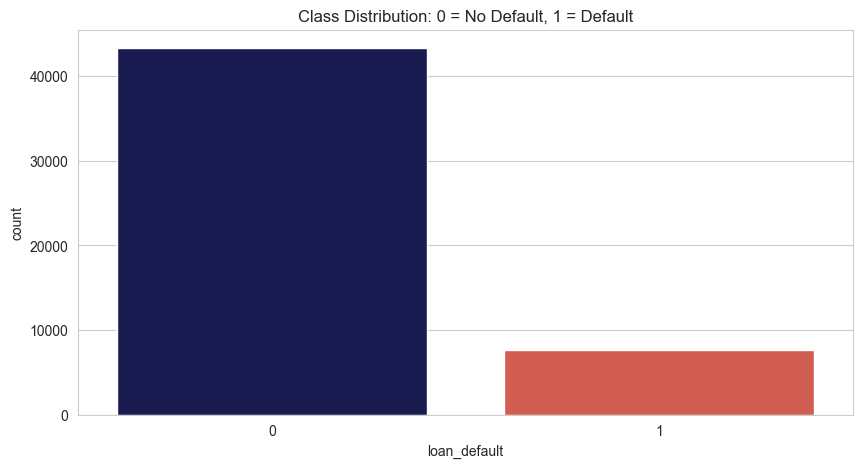

In [16]:

print(df['loan_default'].value_counts())
print("\nPercentage:")
print(df['loan_default'].value_counts(normalize=True) * 100)

# Visualize
sns.countplot(x='loan_default', data=df, palette=["#111359", '#e74c3c'])
plt.title('Class Distribution: 0 = No Default, 1 = Default')
plt.show()

**Class Imbalance — What This Means for Modelling**

- The dataset is imbalanced at roughly 85:15 — 43,342 non-defaults vs 7,658 defaults, a ~5.7:1 ratio.
- Accuracy is a misleading metric here — a dummy model that always predicts 'no default' already scores 85% without learning anything useful.
- I'll address the imbalance using class weights or SMOTE, and evaluate on recall, precision-recall AUC, and ROC-AUC rather than plain accuracy.
- The minority class still has 7,658 samples — large enough for models to learn meaningful patterns without being starved of signal.
- Recall on class 1 (defaulters) is the primary metric that matters here — the cost of missing a real defaulter far outweighs the cost of a false alarm.

In [17]:
import os

print("data/processed/ files:")
for f in os.listdir('../data/processed'):
    size_mb = os.path.getsize(f'../data/processed/{f}') / (1024*1024)
    print(f"  {f} ({size_mb:.2f} MB)")

print("\nmodels/ files:")
if os.path.exists('../models'):
    for f in os.listdir('../models'):
        size_kb = os.path.getsize(f'../models/{f}') / 1024
        print(f"  {f} ({size_kb:.2f} KB)")
else:
    print("  Folder doesn't exist!")

data/processed/ files:
  X_test.csv (6.04 MB)
  X_train.csv (24.16 MB)
  y_test.csv (0.03 MB)
  y_train.csv (0.11 MB)

models/ files:
  baseline_results.json (0.55 KB)
  feature_columns.pkl (1.07 KB)
  final_pipeline.pkl (510.82 KB)
  logistic_regression.pkl (2.80 KB)
  numeric_columns.pkl (0.59 KB)
  random_forest.pkl (51947.79 KB)
  scaler.pkl (2.29 KB)
  xgboost_baseline.pkl (464.57 KB)
  xgboost_best_params.pkl (0.07 KB)
  xgboost_tuned.pkl (506.80 KB)


Exploratory Data Aanlysis

Target vs Numeric features


* Credit score is the strongest numeric risk indicator, with defaults heavily concentrated below 620, while abnormal scores above the valid range require capping to avoid misleading the model.
* Past repayment behaviour forms the most powerful predictive cluster, as previous defaults, missed payments, late payments, and payment delays consistently align with higher default risk.
* Lower on-time payment ratios strongly correlate with defaults, especially below 70%, making it an effective feature for creating risk-based bins or thresholds.
* High loan-to-income ratios indicate financial stress, with borrowers above 2× income showing significantly higher default likelihood and extreme values needing outlier treatment.
* Financial stability and liquidity matter more than raw income, as unstable earnings, short employment tenure, and near-zero balances are commonly observed among defaulters.


Target vs Categorical features

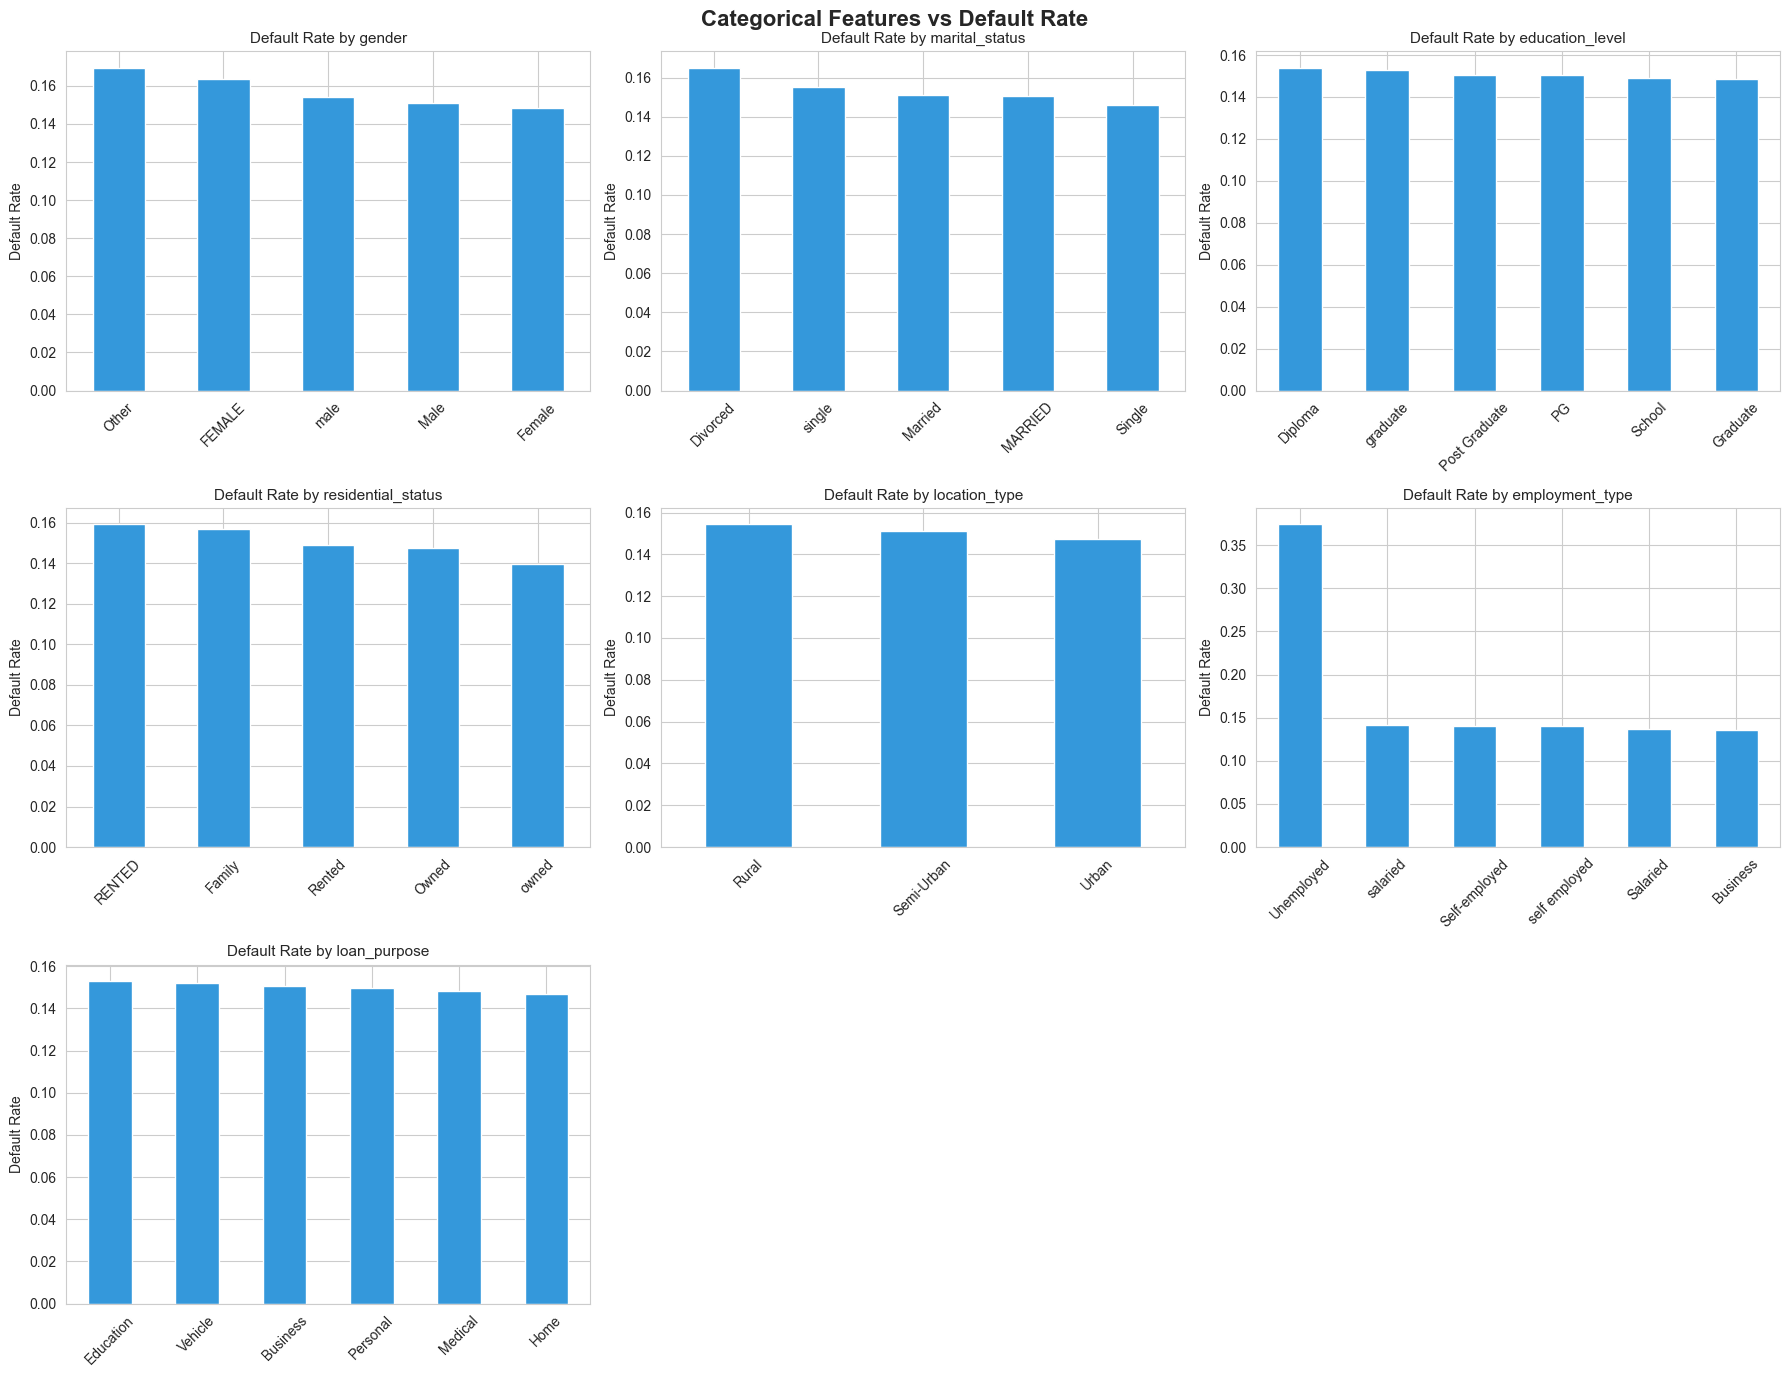

In [22]:


# Categorical features to analyze
categorical_features = ['gender', 'marital_status', 'education_level',
                        'residential_status', 'location_type',
                        'employment_type', 'loan_purpose']

# Create grid showing default rate per category
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    # Calculate default rate per category
    default_rate = df.groupby(col)['loan_default'].mean().sort_values(ascending=False)
    default_rate.plot(kind='bar', ax=axes[i], color='#3498db')
    axes[i].set_title(f'Default Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Default Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(len(categorical_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Default Rate', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\projects\loan_default_prediction\reports\eda_target_vs_categorical.png',
            dpi=100,
            bbox_inches='tight')
plt.show()



* Employment type is the strongest categorical risk indicator, with unemployed applicants showing significantly higher default rates compared to salaried borrowers, making one-hot encoding essential.
* Semi-urban borrowers unexpectedly show the lowest default rates, suggesting underlying income or employment composition effects that should be validated further.
* Loan purpose provides very weak standalone predictive value since default rates remain nearly identical across categories, though it may still help through interaction features.
* Demographic variables such as gender, marital status, education, and residential status contribute minimal direct separation and are more useful for interaction-based modelling.
* Inconsistent category labels fragment groups and distort default statistics, making category standardisation a mandatory preprocessing step before analysis or modelling.
